In [3]:
%pip install matplotlib

  Using cached matplotlib-3.10.9-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
Using cached matplotlib-3.10.9-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.8 MB)
Using cached contourpy-1.3.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (355 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 2.6 MB/s  0:00:01m0:00:0100:01
Using cached kiwisolver-1.5.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (1.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [matplotlib]5 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [14]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

# 여기에 실제 head camera 이미지 경로 넣기
img_path = Path("/home/reality/seungmi/datasets/pi0_dataset_v43/images/chunk-000/observation.images.wrist_left/episode_000000_frame_000001.jpg")

img_bgr = cv2.imread(str(img_path))
assert img_bgr is not None, f"이미지를 못 읽었음: {img_path}"

img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Original")
plt.show()

AssertionError: 이미지를 못 읽었음: /home/reality/seungmi/datasets/pi0_dataset_v43/images/chunk-000/observation.images.wrist_left/episode_000000_frame_000001.jpg

In [11]:
import cv2
import matplotlib.pyplot as plt

def square_crop_bottom(img, y2r=1.0, crop_hr=0.78, center_xr=0.50, out_size=256):
    h, w = img.shape[:2]

    crop_h = int(h * crop_hr)
    crop_w = crop_h  # 1:1 유지

    y2 = int(h * y2r)
    y1 = y2 - crop_h

    cx = int(w * center_xr)
    x1 = cx - crop_w // 2
    x2 = x1 + crop_w

    # 이미지 범위 보정
    if y1 < 0:
        y1 = 0
        y2 = crop_h

    if x1 < 0:
        x1 = 0
        x2 = crop_w

    if x2 > w:
        x2 = w
        x1 = w - crop_w

    crop = img[y1:y2, x1:x2]
    crop = cv2.resize(crop, (out_size, out_size))
    return crop, (x1, y1, x2, y2)

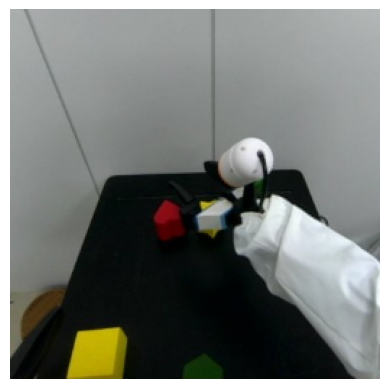

(133, 106, 507, 480)


In [12]:
crop, box = square_crop_bottom(
    img,
    y2r=1.0,
    crop_hr=0.78,
    center_xr=0.50,
    out_size=256
)

plt.imshow(crop)
plt.axis("off")
plt.show()

print(box)

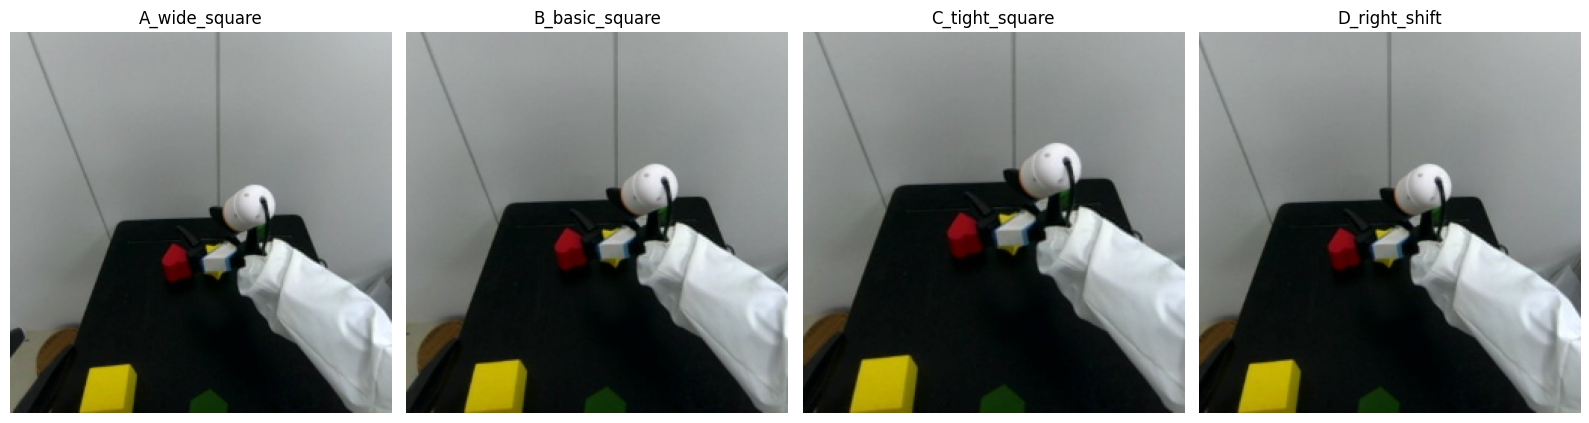

In [13]:
configs = {
    "A_wide_square":  {"crop_hr": 0.85, "center_xr": 0.50},
    "B_basic_square": {"crop_hr": 0.78, "center_xr": 0.50},
    "C_tight_square": {"crop_hr": 0.72, "center_xr": 0.50},
    "D_right_shift":  {"crop_hr": 0.78, "center_xr": 0.53},
}

plt.figure(figsize=(16, 8))

for i, (name, cfg) in enumerate(configs.items()):
    crop_img, box = square_crop_bottom(
        img,
        y2r=1.0,
        crop_hr=cfg["crop_hr"],
        center_xr=cfg["center_xr"],
        out_size=256
    )

    plt.subplot(1, len(configs), i + 1)
    plt.imshow(crop_img)
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
from PIL import Image
from pathlib import Path

root = Path("/home/reality/seungmi/datasets/pi0_dataset_v43/images/chunk-000/observation.images.wrist_left")

bad_files = []

for p in root.glob("*.jpg"):
    try:
        with Image.open(p) as img:
            img.verify()
    except Exception as e:
        bad_files.append((str(p), str(e)))

print("bad image count:", len(bad_files))

for f, e in bad_files[:20]:
    print(f, "=>", e)

bad image count: 51220
/home/reality/seungmi/datasets/pi0_dataset_v43/images/chunk-000/observation.images.wrist_left/episode_000274_frame_000168.jpg => cannot identify image file '/home/reality/seungmi/datasets/pi0_dataset_v43/images/chunk-000/observation.images.wrist_left/episode_000274_frame_000168.jpg'
/home/reality/seungmi/datasets/pi0_dataset_v43/images/chunk-000/observation.images.wrist_left/episode_000191_frame_000127.jpg => cannot identify image file '/home/reality/seungmi/datasets/pi0_dataset_v43/images/chunk-000/observation.images.wrist_left/episode_000191_frame_000127.jpg'
/home/reality/seungmi/datasets/pi0_dataset_v43/images/chunk-000/observation.images.wrist_left/episode_000051_frame_000153.jpg => cannot identify image file '/home/reality/seungmi/datasets/pi0_dataset_v43/images/chunk-000/observation.images.wrist_left/episode_000051_frame_000153.jpg'
/home/reality/seungmi/datasets/pi0_dataset_v43/images/chunk-000/observation.images.wrist_left/episode_000024_frame_000055.jpg